# Prophet

Prophet is an open-source forecasting model developed by Facebook (Meta) designed specifically for time series forecasting. It focuses on providing accurate forecasts with minimal manual tuning and is well-suited for business-related time series such as sales, demand, traffic, and activity metrics.

## Data preparation
In this section, we define our evaluation metrics and load the dataset. The data is imported using the **load_data()** function from our utils.py file. We then split the dataset into training and testing sets using an 80:20 ratio.

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import load_data, check_stationarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [65]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

    y_test = np.array(y_test)
    y_pred = np.array(y_pred)

    residuals = y_test - y_pred
    std = np.std(residuals, ddof=1)

    print("Standard Deviation of Residuals:", std)

In [66]:
loaded_data = load_data()
data = pd.DataFrame({
    'date': loaded_data['date'],
    'y': loaded_data['tmed']
})

data.rename(columns={'date': 'ds', 'value': 'y'}, inplace=True)

data

c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data[f'lagged_tdiff_{lag}'] = selected_data['tdiff'].shift(lag)
c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

,ds,y
date,,
1994-01-01,1994-01-01,8.84
1994-02-01,1994-02-01,9.11
1994-03-01,1994-03-01,13.96
1994-04-01,1994-04-01,12.89
1994-05-01,1994-05-01,15.46
...,...,...
2019-09-01,2019-09-01,20.95
2019-10-01,2019-10-01,16.75
2019-11-01,2019-11-01,12.12


In [67]:
# Use first 80% for training, last 20% for testing
split_idx = int(len(data)*0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(columns=['y'])
y_train = train['y']
X_test = test.drop(columns=['y'])
y_test = test['y']

print(len(test))
print(train.dtypes)
y_test

63
ds    datetime64[ns]
y            float64
dtype: object


date
2014-11-01    13.21
2014-12-01     8.58
2015-01-01     8.25
2015-02-01     8.73
2015-03-01    12.18
              ...  
2019-09-01    20.95
2019-10-01    16.75
2019-11-01    12.12
2019-12-01    10.99
2020-01-01     9.59
Name: y, Length: 63, dtype: float64

## Modelling
Here we import and use prophet in a simple forecasting scenario with no use of rolling windows.

In [68]:
from prophet import Prophet

# Fit Prophet model
model = Prophet()
model.fit(train)

# Create future dataframe for predictions
future = model.make_future_dataframe(periods=len(test), freq='MS')

future

20:26:44 - cmdstanpy - INFO - Chain [1] start processing
20:26:44 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,1994-01-01
1,1994-02-01
2,1994-03-01
3,1994-04-01
4,1994-05-01
...,...
308,2019-09-01
309,2019-10-01
310,2019-11-01
311,2019-12-01


In [69]:
# Generate forecast
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,1994-01-01,9.345742,7.913043,10.732699
1,1994-02-01,10.075078,8.561216,11.489229
2,1994-03-01,12.670964,11.261491,14.052459
3,1994-04-01,14.405861,13.041786,15.836365
4,1994-05-01,16.947071,15.413465,18.324796


In [70]:
# Evaluate the model
evaluate(y_test, forecast['yhat'][-len(test):])

MAE: 1.019298474802989
RMSE: 1.2610828393037985
Standard Deviation of Residuals: 1.1957701493040913


Text(0.5, 1.0, 'Prophet Forecast')

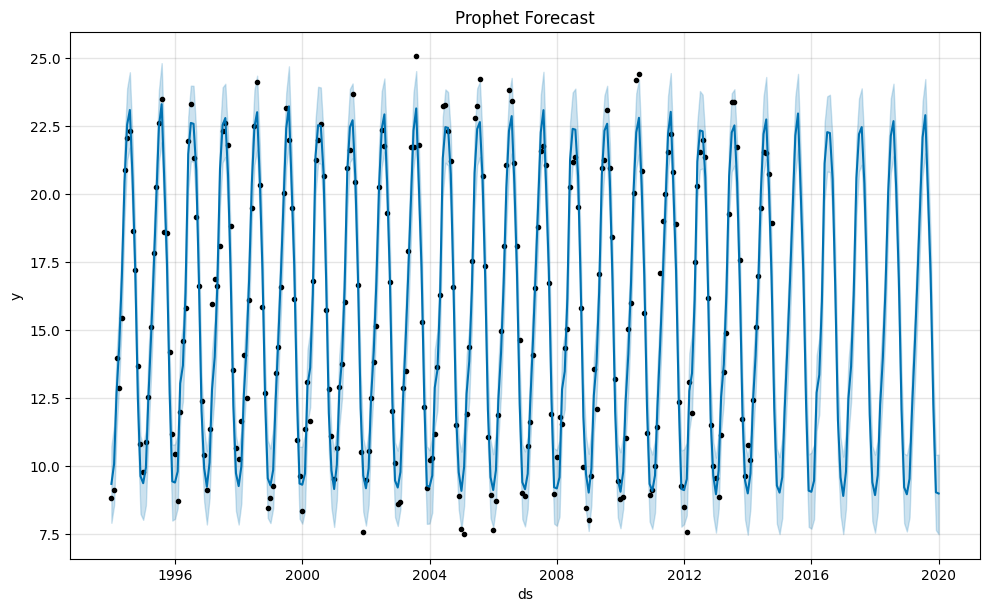

In [71]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")

Text(0.5, 1.02, 'Prophet Forecast Components')

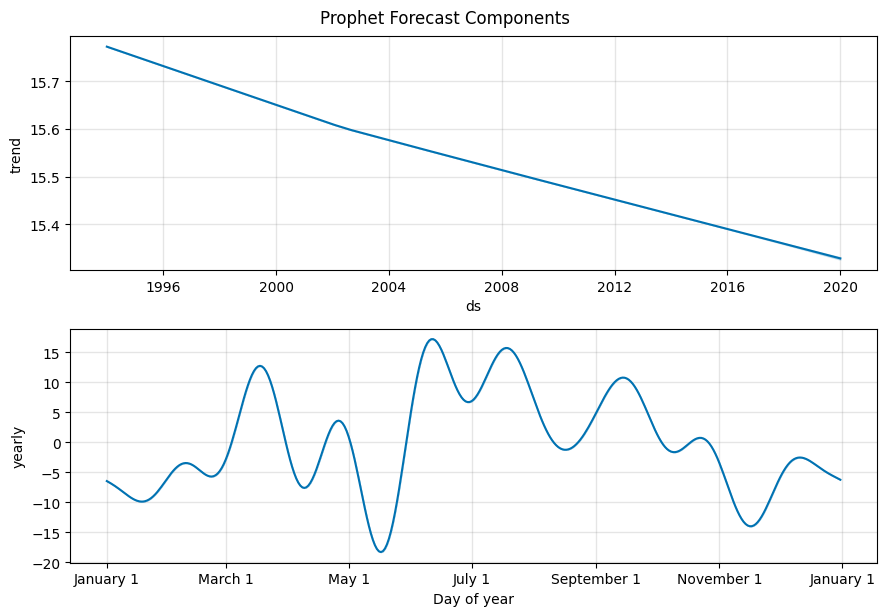

In [72]:
# Plot forecast components
fig2 = model.plot_components(forecast)
plt.suptitle("Prophet Forecast Components", y=1.02)

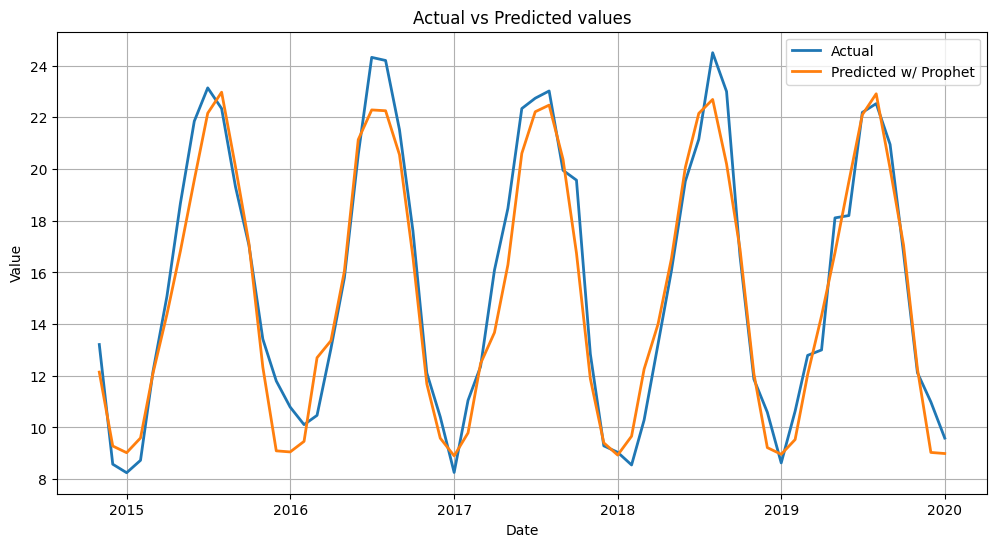

In [73]:
# Filter forecast to only the test dates
forecast_test = forecast.set_index('ds').loc[y_test.index]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, forecast_test['yhat'], label="Predicted w/ Prophet", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

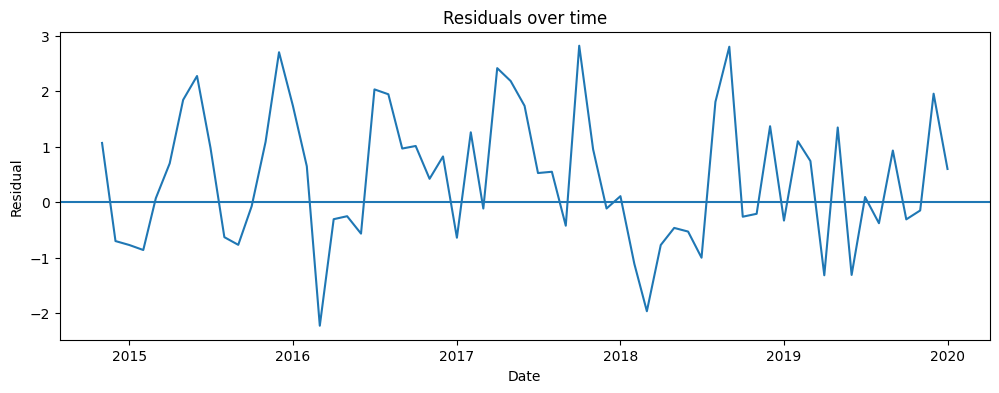

In [74]:
residuals = y_test - forecast_test['yhat']

plt.figure(figsize=(12, 4))
plt.plot(forecast_test.index, residuals)
plt.axhline(0)
plt.title("Residuals over time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

## Hyperparameter Tuning
In this section, we tune Prophet’s hyperparameters to identify the parameter combination that yields the best performance for our dataset. To achieve this, we use Prophet’s built-in diagnostic tools, **cross_validation** and **performance_metrics**.

The hyperparameters that we tune are:

* **changepoint_prior_scale**: This is probably the most impactful parameter. It determines the flexibility of the trend, and in particular how much the trend changes at the trend changepoints. If it is too small, the trend will be underfit and variance that should have been modeled with trend changes will instead end up being handled with the noise term. If it is too large, the trend will overfit and in the most extreme case the trend will capture yearly seasonality;

* **seasonality_prior_scale**: This parameter controls the flexibility of the seasonality. Similarly, a large value allows the seasonality to fit large fluctuations, a small value shrinks the magnitude of the seasonality;

* **seasonality_mode**: This parameters determines if the model should model an additive or multiplicative seasonality. Options are "additive" or "multiplicative";

* **yearly_seasonality**: Indicates whether yearly seasonality should be included in the model. Although the dataset exhibits yearly seasonality, we also tune this parameter to check whether disabling it might yield better results.

In [75]:
from prophet.diagnostics import performance_metrics
from prophet.diagnostics import cross_validation
import itertools

# Define the parameter grid
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    "seasonality_mode": ['additive', 'multiplicative']
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(data)  # Fit model with given params
    df_cv = cross_validation(m, initial="7304 days", horizon='1826 days', period= "30 days", parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = tuning_results.sort_values(by='rmse').iloc[0].to_dict()
print(best_params)


20:26:45 - cmdstanpy - INFO - Chain [1] start processing
20:26:45 - cmdstanpy - INFO - Chain [1] done processing
20:26:45 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
20:26:45 - cmdstanpy - INFO - Chain [1] start processing
20:26:45 - cmdstanpy - INFO - Chain [1] done processing
20:26:50 - cmdstanpy - INFO - Chain [1] start processing
20:26:51 - cmdstanpy - INFO - Chain [1] done processing
20:26:51 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
20:26:51 - cmdstanpy - INFO - Chain [1] start processing
20:26:51 - cmdstanpy - INFO - Chain [1] done processing
20:26:54 - cmdstanpy - INFO - Chain [1] start processing
20:26:54 - cmdstanpy - INFO - Chain [1] done processing
20:26:54 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
20:26:55 - c

{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive', 'rmse': 1.2184318570295491}


20:28:33 - cmdstanpy - INFO - Chain [1] start processing
20:28:33 - cmdstanpy - INFO - Chain [1] done processing


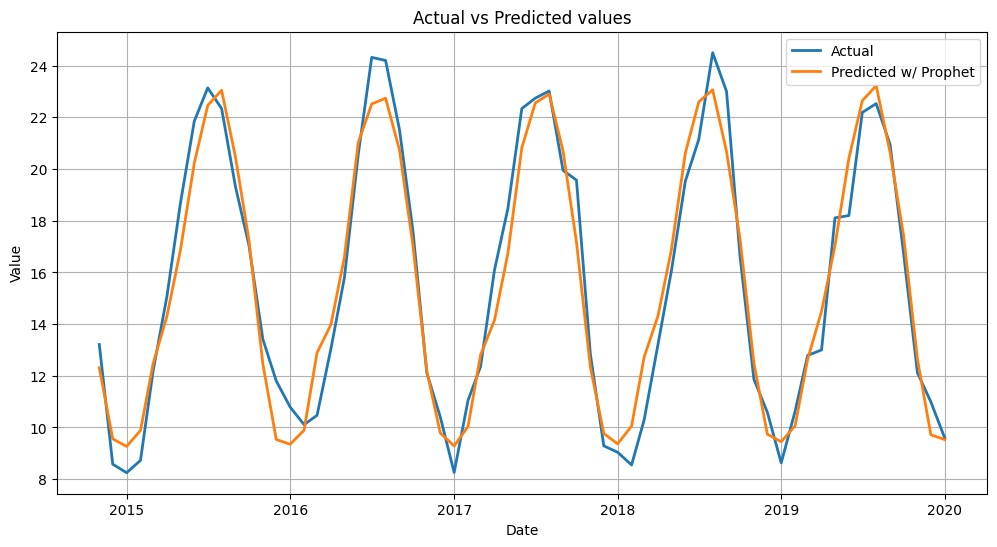

MAE: 1.0015615545704715
RMSE: 1.1859689952904817
Standard Deviation of Residuals: 1.1941391603953935


In [76]:
# Fit the model with the best parameters
model = Prophet(changepoint_prior_scale=best_params['changepoint_prior_scale'],
                seasonality_prior_scale=best_params['seasonality_prior_scale'],
                seasonality_mode=best_params['seasonality_mode'])
model.fit(train)
future = model.make_future_dataframe(periods=len(test), freq='MS')

forecast = model.predict(future)

# Filter forecast to only the test dates
forecast_test = forecast.set_index('ds').loc[y_test.index]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, forecast_test['yhat'], label="Predicted w/ Prophet", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()
evaluate(y_test, forecast['yhat'][-len(test):])

## Modelling with Rolling window
In this section, we take the hyperparameters obtained from the previous step and apply them to a rolling-window forecasting setup. Our rolling window uses a training period of 9 years followed by a 1-year forecasting horizon.

In [85]:
window_size = 96  # 8 years
forecast_horizon = 24  # 2-year ahead

preds = []
actuals = []
dates = []

lb_results = []
rmse_per_fold = []

for start in range(0, len(data) - window_size - forecast_horizon + 1, forecast_horizon):

    # Training and test windows
    train_window = data.iloc[start:start + window_size]
    test_window = data.iloc[start + window_size:start + window_size + forecast_horizon]

    # Initialize Prophet model with best params
    model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode']
    )

    # Fit model
    model.fit(train_window)

    # Forecast one full horizon
    future = model.make_future_dataframe(periods=forecast_horizon, freq='MS')
    forecast = model.predict(future)

    # Extract forecast matching the test-window dates
    forecast_window = (
        forecast.set_index('ds')
                .loc[test_window['ds'].values]  # aligned on timestamp
    )

    # Store values
    preds.extend(forecast_window['yhat'].values)
    actuals.extend(test_window['y'].values)
    dates.extend(test_window['ds'].values)

    # Residuals for this window
    residuals = test_window['y'].values - forecast_window['yhat'].values

    # Ljung–Box at seasonal lag
    lb = acorr_ljungbox(
        residuals,
        lags=[12],
        return_df=True
    )

    lb_results.append({
        'ds': test_window['ds'].iloc[-1],   # end of forecast window
        'lb_stat': lb['lb_stat'].iloc[0],
        'p_value': lb['lb_pvalue'].iloc[0]
    })
    rmse = np.sqrt(mean_squared_error(test_window['y'].values, forecast_window['yhat'].values))
    rmse_per_fold.append(rmse)

rmse_mean = np.mean(rmse_per_fold)
rmse_std = np.std(rmse_per_fold, ddof=1)  # sample std

print(f"Mean RMSE: {rmse_mean:.3f}")
print(f"Std. Dev. RMSE: {rmse_std:.3f}")

#DataFrame for plotting
results_df = pd.DataFrame({
    'ds': dates,
    'actual': actuals,
    'predicted': preds
})
evaluate(actuals, preds)

20:34:48 - cmdstanpy - INFO - Chain [1] start processing
20:34:49 - cmdstanpy - INFO - Chain [1] done processing
20:34:49 - cmdstanpy - INFO - Chain [1] start processing
20:34:49 - cmdstanpy - INFO - Chain [1] done processing
20:34:50 - cmdstanpy - INFO - Chain [1] start processing
20:34:50 - cmdstanpy - INFO - Chain [1] done processing
20:34:50 - cmdstanpy - INFO - Chain [1] start processing
20:34:51 - cmdstanpy - INFO - Chain [1] done processing
20:34:51 - cmdstanpy - INFO - Chain [1] start processing
20:34:51 - cmdstanpy - INFO - Chain [1] done processing
20:34:52 - cmdstanpy - INFO - Chain [1] start processing
20:34:52 - cmdstanpy - INFO - Chain [1] done processing
20:34:52 - cmdstanpy - INFO - Chain [1] start processing
20:34:53 - cmdstanpy - INFO - Chain [1] done processing
20:34:53 - cmdstanpy - INFO - Chain [1] start processing
20:34:53 - cmdstanpy - INFO - Chain [1] done processing
20:34:53 - cmdstanpy - INFO - Chain [1] start processing
20:34:54 - cmdstanpy - INFO - Chain [1]

Mean RMSE: 1.304
Std. Dev. RMSE: 0.194
MAE: 1.0678407793485232
RMSE: 1.3164068873221733
Standard Deviation of Residuals: 1.278771518839631


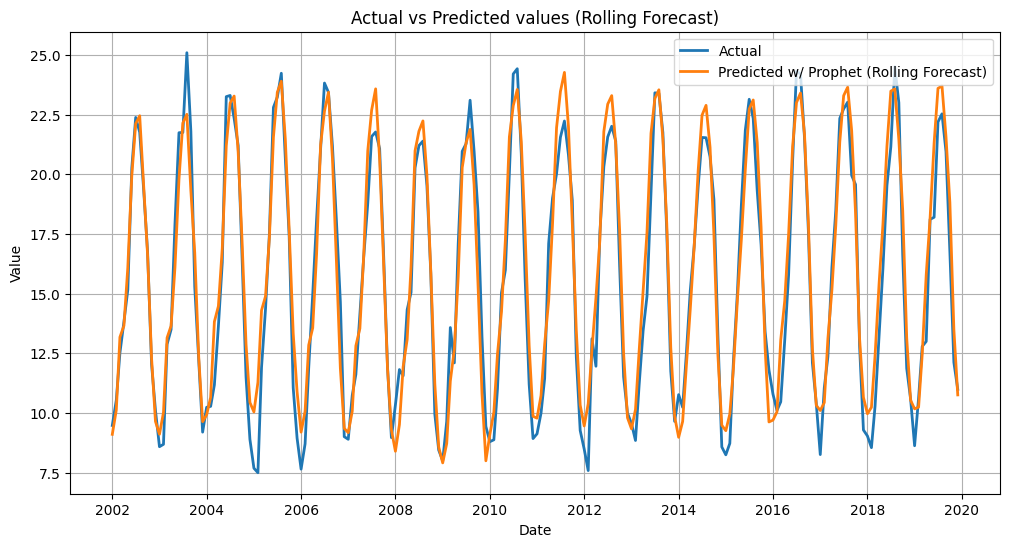

In [78]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(results_df["ds"], results_df["actual"], label="Actual", linewidth=2)
plt.plot(results_df["ds"], results_df["predicted"], label="Predicted w/ Prophet (Rolling Forecast)", linewidth=2)
plt.title("Actual vs Predicted values (Rolling Forecast)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

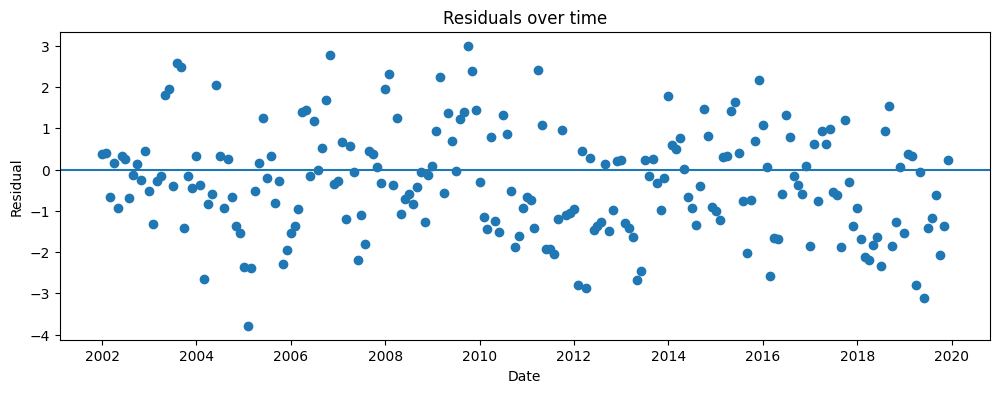

In [79]:
residuals = np.array(actuals) - np.array(preds)

plt.figure(figsize=(12, 4))
plt.scatter(results_df["ds"], residuals)
plt.axhline(0)
plt.title("Residuals over time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

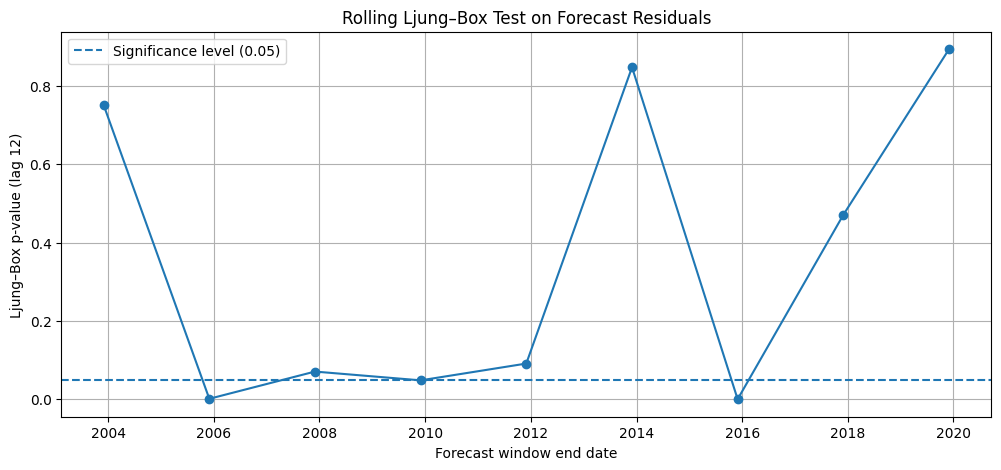

In [80]:
from plots import plot_lb_test

lb_df = pd.DataFrame(lb_results)

plot_lb_test(lb_df, rolling_window=True)

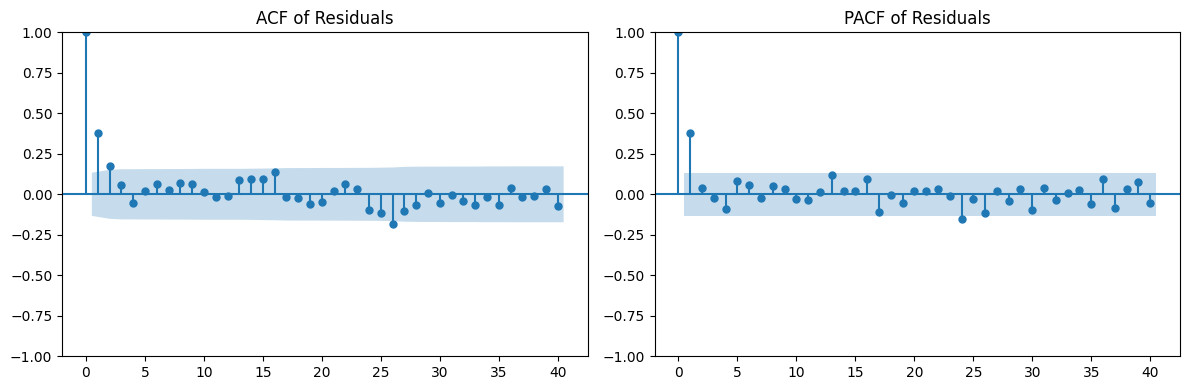

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, lags=40, ax=axes[0])
axes[0].set_title("ACF of Residuals")

plot_pacf(residuals, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Residuals")

plt.tight_layout()
plt.show()

## ACF and PACF computation
In this section we compute the ACF and the PACF of the residuals to diagnose if the model is working well or not.

In [82]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Initialize Prophet model with best params
model = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode']
)
model.fit(data)

# Cross-validated predictions (out-of-sample forecasts to avoid optimistic diagnostics.)
df_cv = cross_validation(
    model,
    horizon="365 days",
    period="30 days",
    initial="7304 days"
)

# Residuals
df_cv['residual'] = df_cv['y'] - df_cv['yhat']
residuals = df_cv['residual']

20:28:40 - cmdstanpy - INFO - Chain [1] start processing
20:28:40 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/61 [00:00<?, ?it/s]20:28:40 - cmdstanpy - INFO - Chain [1] start processing
20:28:40 - cmdstanpy - INFO - Chain [1] done processing
  2%|▏         | 1/61 [00:00<00:09,  6.02it/s]20:28:40 - cmdstanpy - INFO - Chain [1] start processing
20:28:40 - cmdstanpy - INFO - Chain [1] done processing
  3%|▎         | 2/61 [00:00<00:09,  6.21it/s]20:28:40 - cmdstanpy - INFO - Chain [1] start processing
20:28:41 - cmdstanpy - INFO - Chain [1] done processing
  5%|▍         | 3/61 [00:00<00:09,  6.11it/s]20:28:41 - cmdstanpy - INFO - Chain [1] start processing
20:28:41 - cmdstanpy - INFO - Chain [1] done processing
  7%|▋         | 4/61 [00:00<00:09,  6.10it/s]20:28:41 - cmdstanpy - INFO - Chain [1] start processing
20:28:41 - cmdstanpy - INFO - Chain [1] done processing
  8%|▊         | 5/61 [00:00<00:09,  6.18it/s]20:28:41 - cmdstanpy - INFO - Chain [1] start processi

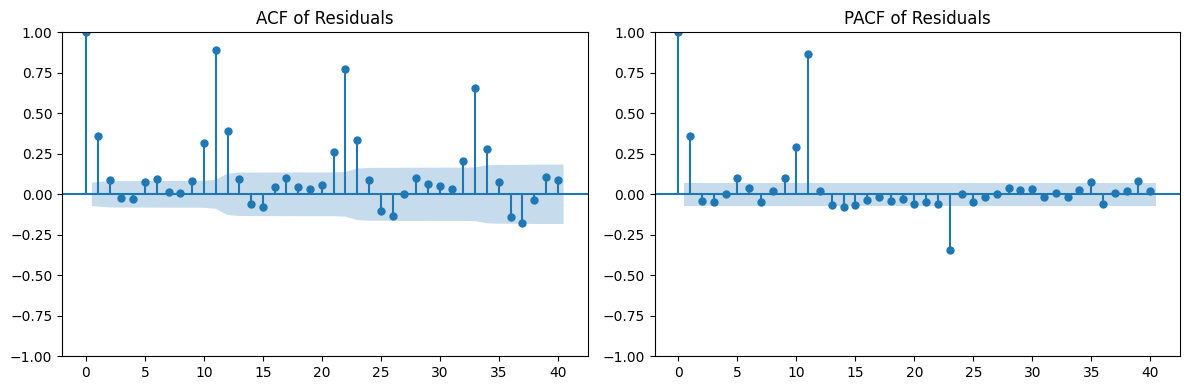

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, lags=40, ax=axes[0])
axes[0].set_title("ACF of Residuals")

plot_pacf(residuals, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Residuals")

plt.tight_layout()
plt.show()

Given the plots of the ACF and PACF, we can surmise these things:
* Most autocorrelation values lie within the confidence bounds;
* Most autocorrelation values fluctuate around zero;
* There are clear significant spikes at lags 12, 24, etc... for the ACF and clear spikes for lag 12 for the PACF.

Based on the above, we conclude that the model successfully captures the overall trend and that there is no strong short-term autoregressive structure remaining in the residuals. However, the model does not fully capture the annual seasonal patterns, despite yearly seasonality being explicitly enabled. This behavior is likely due to the dataset showing cyclostationarity at lag 12.

Since Prophet is specifically designed to model seasonal effects directly, we avoid applying seasonal differencing at lag 12. Altering the dataset is not recommended for Prophet, as it would remove seasonal information that the model relies on for forecasting. Instead, we try to solve this issue by adjusting the model’s seasonal parameters to better capture the underlying annual cycle.


20:28:51 - cmdstanpy - INFO - Chain [1] start processing
20:28:51 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/61 [00:00<?, ?it/s]20:28:51 - cmdstanpy - INFO - Chain [1] start processing
20:28:51 - cmdstanpy - INFO - Chain [1] done processing
  2%|▏         | 1/61 [00:00<00:11,  5.03it/s]20:28:51 - cmdstanpy - INFO - Chain [1] start processing
20:28:51 - cmdstanpy - INFO - Chain [1] done processing
  3%|▎         | 2/61 [00:00<00:12,  4.69it/s]20:28:51 - cmdstanpy - INFO - Chain [1] start processing
20:28:51 - cmdstanpy - INFO - Chain [1] done processing
  5%|▍         | 3/61 [00:00<00:11,  4.84it/s]20:28:52 - cmdstanpy - INFO - Chain [1] start processing
20:28:52 - cmdstanpy - INFO - Chain [1] done processing
  7%|▋         | 4/61 [00:00<00:11,  4.75it/s]20:28:52 - cmdstanpy - INFO - Chain [1] start processing
20:28:52 - cmdstanpy - INFO - Chain [1] done processing
  8%|▊         | 5/61 [00:01<00:12,  4.60it/s]20:28:52 - cmdstanpy - INFO - Chain [1] start processi

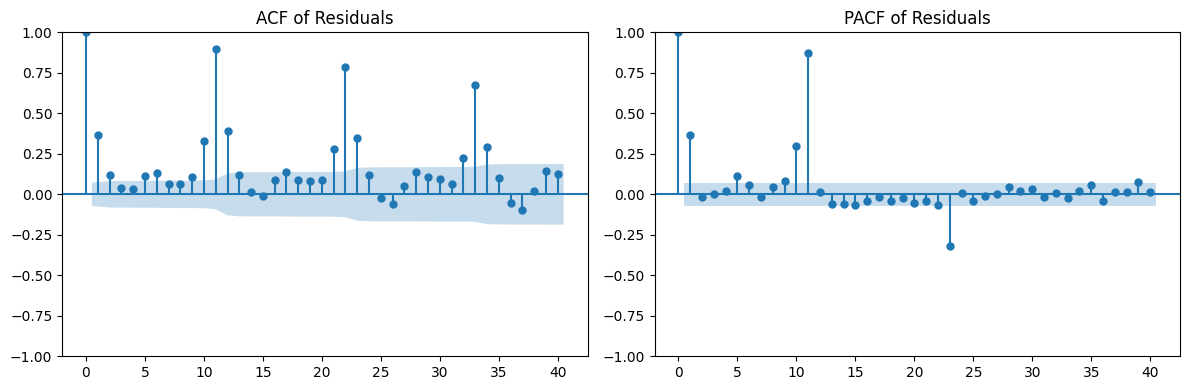

In [84]:
model = Prophet(
    yearly_seasonality=False,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode']
)

model.add_seasonality(
    name='yearly',
    period=365.25,
    fourier_order=35  # increase flexibility
)

model.fit(data)

# Cross-validated predictions (out-of-sample forecasts to avoid optimistic diagnostics.)
df_cv = cross_validation(
    model,
    horizon="365 days",
    period="30 days",
    initial="7304 days"
)

# Residuals
residuals = df_cv['y'] - df_cv['yhat']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, lags=40, ax=axes[0])
axes[0].set_title("ACF of Residuals")

plot_pacf(residuals, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Residuals")

plt.tight_layout()
plt.show()

Increasing the Fourier order of the yearly seasonal component does not eliminate the residual autocorrelation at lag 12. This indicates the presence of time-varying annual seasonality (cyclostationarity), which cannot be fully captured by Prophet’s global seasonal formulation (Prophet assumes seasonality is globally consistent overtime). Nevertheless, the model adequately captures the overall trend and short-term dynamics, and the rolling-window forecasting strategy helps mitigate the impact of this remaining seasonal structure.